<div align="center" style="text-align: center; padding: 60px 0;">

<h1 style="text-align: center;">Monitoring glacier retreat and glacial lake growth in the Mount Everest massif with Sentinel-2 (2017–2025)</h1>

<br>

<h2 style="text-align: center;">Remote Sensing &amp; Computer Vision</h2>

<br><br>

<p style="text-align: center; font-size: 18px;"><b>Authors:</b> Luka Rondal &amp; Tanguy Mandrillon</p>

<p style="text-align: center; font-size: 18px;">2026</p>

</div>


## **Context**
Glaciers of the Everest massif (Khumbu, Rongbuk, Kangshung, Ngozumpa, 
Imja–Lhotse Shar...) are losing mass because of rising temperatures. Two visible 
consequences are the shrinking of clean ice/snow-covered surfaces and the growth of 
pro-glacial lakes such as Imja Tsho, which increases the risk of glacial lake outburst 
floods (GLOF) for the valleys downstream. The goal is to quantify these two phenomena 
over the last decade. 

## 1. Bibliography
In this section, we will define the scope and make sope assumption for our analysis.

### **Geography analysis**
We will chose a glacier and a lake to analyze.

| Type | Name | Description | Source |
|:---|:---|:---|:---|
| Glacier | Khumbu Glacier | Located in north-eastern Nepal, between Mount Everest and the Lhotse–Nuptse ridge. It is one of the highest glaciers in the world and includes the Khumbu Icefall on the standard Everest climbing route. Its lower tongue is largely debris-covered. | [Wikipedia – Khumbu Glacier](https://en.wikipedia.org/wiki/Khumbu_Glacier) |
| Lake | Imja Tsho | Pro-glacial lake at about 5,000 m altitude, at the terminus of the Imja and Lhotse Shar glaciers, south of Everest. It formed from melt ponds in the second half of the 20th century and is one of the fastest-growing glacial lakes in the Himalaya, with a significant GLOF risk for the valleys downstream. | [Wikipedia – Imja Tsho](https://en.wikipedia.org/wiki/Imja_Tsho) |

### **Spectral indices: NDSI and NDWI**

To separate our classes we use two **normalized difference indices**. A normalized difference index compares the reflectance of a pixel in two spectral bands where the target surface behaves very differently:

$$\text{Index} = \frac{\rho_1 - \rho_2}{\rho_1 + \rho_2} \in [-1, 1]$$

The normalization makes the index less sensitive to illumination differences (slopes, shadows, sun angle), which matters in a steep mountain area like the Everest massif.

**[NDSI – Normalized Difference Snow Index](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndsi/)**

$$NDSI = \frac{B03 - B11}{B03 + B11}$$

- `B03` = green (560 nm, 10 m) and `B11` = short-wave infrared, SWIR (1610 nm, 20 m).
- **What it shows:** snow and ice reflect a lot of visible light but absorb strongly in the SWIR, so they have a **high NDSI**. Rock, soil and debris reflect about the same amount in both bands, so their NDSI is **close to 0 or negative**. Clouds are bright in both bands, which gives a low NDSI and lets the index separate snow from most clouds.
- **Threshold:** a pixel is classified as snow/ice when **NDSI > 0.42** (Hall et al., 1995).
- **Limitation:** NDSI cannot tell snow from clean glacier ice (both are high), so we merge them into one **snow/ice** class. Ice covered by debris looks like rock and is **not** detected.

**[NDWI – Normalized Difference Water Index](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndwi/)**

$$NDWI = \frac{B03 - B08}{B03 + B08}$$

- `B03` = green (560 nm, 10 m) and `B08` = near infrared, NIR (842 nm, 10 m).
- **What it shows:** open water absorbs almost all NIR light, so it has a **positive NDWI**. Vegetation and bare soil reflect more NIR than green, so they have a **negative NDWI**.
- **Threshold:** the threshold depends on the source. McFeeters (1996) uses **NDWI > 0** for water, while Sentinel Hub states that *"index values greater than 0.5 usually correspond to water bodies"*. In a glacier area, a threshold that is too low is risky: snow and clean ice can also have slightly positive NDWI values. A threshold that is too high misses turbid glacial lakes, which carry a lot of sediment. We will therefore **tune the threshold between 0.2 and 0.5** by checking the result on true-colour images of Imja Tsho.
- **Why we need it:** water also has a **high NDSI**, since it absorbs SWIR as well. NDSI alone would classify lakes such as Imja Tsho as ice, so NDWI is used to **separate lakes from ice**.

### **Classification rules**

Each pixel gets one of 4 classes. The order of the tests matters:

| Order | Condition | Class |
|:---:|:---|:---|
| 1 | SCL = 0, 3, 8, 9 or 10 (no data, cloud shadow, clouds, cirrus) | Cloud / no data |
| 2 | NDWI > threshold (0.2 – 0.5, tuned) | Water (glacial lake) |
| 3 | NDSI > 0.4 | Snow / ice |
| 4 | otherwise | Rock / debris |

Water is tested **before** snow/ice because lakes have both a high NDWI and a high NDSI. Area per class = number of pixels × 400 m² (20 m pixels).

## 2. Parameters

All the **variable inputs** of the pipeline are gathered in the next cell. To run the analysis on another area, period or threshold, only this cell has to be modified, then the whole notebook can be re-run.

| Parameter | Value | Justification |
|:---|:---|:---|
| `BBOX_KHUMBU` | 86.79–86.94° E, 27.92–28.02° N | Khumbu Glacier, from its terminus (27.93° N, 86.81° E) up to the Khumbu Icefall and the Western Cwm |
| `BBOX_IMJA_TSHO` | 86.90–86.97° E, 27.88–27.92° N | Imja Tsho (27.90° N, 86.93° E, about 2 km × 650 m) and the tongues of the Imja and Lhotse Shar glaciers that feed it |
| `YEARS` | 2017 → 2025 | One image per year, to follow the trend over the last decade |
| `SEASON_START` / `SEASON_END` | 1 Oct → 30 Nov | Post-monsoon: fewest clouds and minimal seasonal snow, so the snow/ice surface is close to the glacier surface |
| `MAX_CLOUD_COVER` | 20 % | Maximum cloud cover of the selected acquisition |
| `RESOLUTION` | 20 m | Native resolution of B11 (SWIR); same grid for all the bands |
| `NDSI_THRESHOLD` | 0.42 | Snow/ice threshold (see section 1) |
| `NDWI_THRESHOLD` | 0.3 | Water threshold, starting value to tune between 0.2 and 0.5 (see section 1) |
| `SCL_MASK_CLASSES` | 0, 3, 8, 9, 10 | No data, cloud shadow, clouds (medium/high probability), thin cirrus |
| `MAX_MASKED_FRACTION` | 30 % | Years with more masked pixels are flagged as unreliable |

The Copernicus credentials are **not** written in the notebook: they are imported from the separate file `myCopernicusCredentials.py`.

In [12]:
# --- Areas of interest (lon_min, lat_min, lon_max, lat_max) in WGS84 (EPSG:4326)
BBOX_KHUMBU = [86.79, 27.92, 86.94, 28.02]     # Khumbu Glacier: from the terminus (27.93 N, 86.81 E) to the Western Cwm
BBOX_IMJA_TSHO = [86.90, 27.88, 86.97, 27.92]  # Imja Tsho (27.90 N, 86.93 E) + Imja / Lhotse Shar glacier tongues

AOIS = {
    "Khumbu Glacier": BBOX_KHUMBU,
    "Imja Tsho": BBOX_IMJA_TSHO,
}

# --- Period
YEARS = list(range(2017, 2026))  # 2017 -> 2025 (range end is excluded)
SEASON_START = "10-01"           # MM-DD, post-monsoon window
SEASON_END = "11-30"             # MM-DD

# --- Image selection
MAX_CLOUD_COVER = 0.20  # Max cloud cover of the acquisition (0 to 1)
RESOLUTION = 20         # Pixel size in meters (B11 native resolution)

# --- Classification thresholds (see section 1)
NDSI_THRESHOLD = 0.42  # snow/ice if NDSI > NDSI_THRESHOLD
NDWI_THRESHOLD = 0.3   # water if NDWI > NDWI_THRESHOLD (to tune between 0.2 and 0.5)

# --- Cloud / no-data mask from the Scene Classification Layer (SCL)
SCL_MASK_CLASSES = [0, 3, 8, 9, 10]  # no data, cloud shadow, cloud medium/high proba, thin cirrus
MAX_MASKED_FRACTION = 0.30           # years with more masked pixels are flagged

# --- Bands requested to Sentinel Hub (Sentinel-2 L2A)
BANDS = ["B02", "B03", "B04", "B08", "B11", "SCL"]

# --- Derived values
PIXEL_AREA_KM2 = (RESOLUTION * RESOLUTION) / 1e6  # 20 m x 20 m = 400 m2 = 0.0004 km2
TIME_INTERVALS = {year: (f"{year}-{SEASON_START}", f"{year}-{SEASON_END}") for year in YEARS}

for name, bbox in AOIS.items():
    print(f"{name}: {bbox}")
print(f"Years: {YEARS[0]} -> {YEARS[-1]} ({len(YEARS)} images)")
print(f"Season window: {SEASON_START} -> {SEASON_END}")
print(f"Pixel area: {PIXEL_AREA_KM2} km2")

Khumbu Glacier: [86.79, 27.92, 86.94, 28.02]
Imja Tsho: [86.9, 27.88, 86.97, 27.92]
Years: 2017 -> 2025 (9 images)
Season window: 10-01 -> 11-30
Pixel area: 0.0004 km2


Next we configure the connection to the Copernicus Data Space Ecosystem (Sentinel Hub API) and check that the requested image stays under the Sentinel Hub size limit (2500 × 2500 px).

In [13]:
import sys
import importlib
import sentinelhub
import myCopernicusCredentials
importlib.reload(myCopernicusCredentials)

# --- Sentinel Hub configuration (Copernicus Data Space Ecosystem)
config = sentinelhub.SHConfig()
config.sh_client_id = myCopernicusCredentials.client_id
config.sh_client_secret = myCopernicusCredentials.client_secret
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
config.sh_base_url = "https://sh.dataspace.copernicus.eu"

# --- Bounding boxes and image sizes
aoi_bboxes = {}
aoi_sizes = {}
for name, bbox in AOIS.items():
    aoi_bboxes[name] = sentinelhub.BBox(bbox=bbox, crs=sentinelhub.CRS.WGS84)
    aoi_sizes[name] = sentinelhub.bbox_to_dimensions(aoi_bboxes[name], resolution=RESOLUTION)
    print(f"{name}: {aoi_sizes[name][0]} x {aoi_sizes[name][1]} px at {RESOLUTION} m")

    if max(aoi_sizes[name]) > 2500:
        print(f"WARNING: {name} larger than 2500 px, increase RESOLUTION or reduce the bbox")

Khumbu Glacier: 738 x 553 px at 20 m
Imja Tsho: 345 x 221 px at 20 m


In [19]:
import folium
import shapely

# Visual check of the areas of interest
colors = {"Khumbu Glacier": "orange", "Imja Tsho": "red"}

# Base maps: OpenStreetMap by default, satellite imagery selectable in the legend
map = folium.Map(tiles="OpenStreetMap")
folium.TileLayer(tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
                 attr="Esri World Imagery", name="Satellite (Esri)", show=False).add_to(map)

for name, bbox in AOIS.items():
    folium.GeoJson(data=shapely.geometry.box(*bbox),
                   name=f"<span style='color: {colors[name]};'>▬</span> {name}",
                   style_function=lambda x, c=colors[name]: {"color": c, "fillOpacity": 0.05}).add_to(map)

map.add_child(folium.LayerControl(collapsed=False))
# Fit the map on all the areas of interest. folium expects (lat, lon)
lon_min, lat_min = min(b[0] for b in AOIS.values()), min(b[1] for b in AOIS.values())
lon_max, lat_max = max(b[2] for b in AOIS.values()), max(b[3] for b in AOIS.values())
map.fit_bounds([(lat_min, lon_min), (lat_max, lon_max)])
display(map)

## 3. Data acquisition

For each year and each area of interest, we send **one `SentinelHubRequest`** to the Sentinel Hub Processing API on the **Sentinel-2 L2A** collection (surface reflectance, atmospherically corrected).

- **Evalscript:** returns the bands `B02, B03, B04, B08, B11` as **reflectance** (FLOAT32, 0 to ~1), the `SCL` class code and `dataMask` (1 = pixel acquired, 0 = no data). The raw values are kept so the indices can be computed in Python (sections 4 and 5).
- **Time interval:** the post-monsoon window of each year (1 Oct → 30 Nov).
- **`mosaickingOrder = leastCC`:** among all the acquisitions of the window, Sentinel Hub keeps the **least cloudy** one. Tiles with more than `MAX_CLOUD_COVER` are ignored.
- **Resolution:** 20 m. B11 is natively at 20 m, the 10 m bands are resampled on the same grid.
- **Cache:** the responses are saved in `data/sentinelhub/`. Re-running the notebook reloads them from disk instead of downloading them again.

> **Note:** the cloud cover used by `leastCC` is computed on the whole Sentinel-2 tile (100 × 100 km), not on our bounding box. If the least cloudy tile does not cover the whole bbox, pixels from another date can fill the gap. Image quality is therefore checked visually below.

In [20]:
import json
import numpy as np

# --- Bands returned by the evalscript (BANDS from the parameters + dataMask)
OUTPUT_BANDS = BANDS + ["dataMask"]
BAND_INDEX = {band: i for i, band in enumerate(OUTPUT_BANDS)}  # e.g. image[..., BAND_INDEX["B03"]]

# Reflectance for the spectral bands, raw class code (DN) for SCL and dataMask
units = ["DN" if band in ("SCL", "dataMask") else "REFLECTANCE" for band in OUTPUT_BANDS]

evalscript_bands = f"""
//VERSION=3
function setup() {{
    return {{
        input: [{{
            bands: {json.dumps(OUTPUT_BANDS)},
            units: {json.dumps(units)}
        }}],
        output: {{
            bands: {len(OUTPUT_BANDS)},
            sampleType: "FLOAT32"
        }}
    }};
}}

function evaluatePixel(sample) {{
    return [{", ".join(f"sample.{band}" for band in OUTPUT_BANDS)}];
}}
"""

# Sentinel-2 L2A collection on the Copernicus Data Space Ecosystem
S2_L2A = sentinelhub.DataCollection.SENTINEL2_L2A.define_from(name="s2l2a_cdse", service_url=config.sh_base_url)

DATA_FOLDER = "data/sentinelhub"  # local cache of the downloaded images


def download_image(bbox_sh, size, time_interval):
    """Download one least-cloudy Sentinel-2 L2A image (H x W x len(OUTPUT_BANDS), float32)."""
    request = sentinelhub.SentinelHubRequest(
        evalscript=evalscript_bands,
        input_data=[
            sentinelhub.SentinelHubRequest.input_data(
                data_collection=S2_L2A,
                time_interval=time_interval,
                maxcc=MAX_CLOUD_COVER,
                mosaicking_order=sentinelhub.MosaickingOrder.LEAST_CC,
            )
        ],
        responses=[sentinelhub.SentinelHubRequest.output_response("default", sentinelhub.MimeType.TIFF)],
        bbox=bbox_sh,
        size=size,  # WARNING, the output size should be < (2500, 2500)
        data_folder=DATA_FOLDER,
        config=config,
    )
    return request.get_data(save_data=True)[0]  # reloaded from DATA_FOLDER if already downloaded

Before downloading, we query the **Catalog API** to see, for each year, how many acquisitions under `MAX_CLOUD_COVER` exist in the window and which one is the least cloudy (the one that `leastCC` should select). A year with 0 acquisitions will not produce an image: increase `MAX_CLOUD_COVER` or widen the window.

In [21]:
import pandas as pd

# --- Catalog check: which acquisitions are available for each year? (for each area of interest)
catalog = sentinelhub.SentinelHubCatalog(config=config)

catalog_rows = []
for name in AOIS:
    for year, time_interval in TIME_INTERVALS.items():
        results = list(catalog.search(
            S2_L2A,
            bbox=aoi_bboxes[name],
            time=time_interval,
            filter=f"eo:cloud_cover < {MAX_CLOUD_COVER * 100}",
            fields={"include": ["id", "properties.datetime", "properties.eo:cloud_cover"], "exclude": []},
        ))
        row = {"aoi": name, "year": year, "nb_acquisitions": 0, "least_cloudy_date": None, "tile_cloud_cover_%": None}
        if results:
            best = min(results, key=lambda r: r["properties"]["eo:cloud_cover"])
            row["nb_acquisitions"] = len({r["properties"]["datetime"][:10] for r in results})
            row["least_cloudy_date"] = best["properties"]["datetime"][:10]
            row["tile_cloud_cover_%"] = best["properties"]["eo:cloud_cover"]
        catalog_rows.append(row)

catalog_summary = pd.DataFrame(catalog_rows).set_index(["aoi", "year"])
display(catalog_summary)

nb_acquisitions least_cloudy_date  tile_cloud_cover_%
aoi            year                                                       
Khumbu Glacier 2017                8        2017-11-29                0.04
               2018               12        2018-10-15                0.01
               2019                7        2019-11-19                0.00
               2020               10        2020-11-13                0.00
               2021               10        2021-11-28                0.00
               2022                9        2022-11-18                0.00
               2023               10        2023-11-13                0.00
               2024               10        2024-11-07                0.00
               2025               10        2025-11-22                0.00
Imja Tsho      2017                4        2017-11-19                2.29
               2018                6        2018-11-09                1.74
               2019                3        2019-10-15                6.96
               2020                8        2020-10-29                0.01
               2021                8        2021-11-03                2.65
               2022                8        2022-10-24                3.92
               2023                6        2023-11-13                0.84
               2024                4        2024-11-07                3.53
               2025                6        2025-11-17                0.37

We now download the images: 2 areas × 9 years = 18 requests. The first run takes a few minutes, the next ones reload the images from `data/sentinelhub/`.

In [17]:
# --- Download one image per year and per area of interest
# images["Imja Tsho"][2020] -> numpy array (H x W x len(OUTPUT_BANDS))
images = {name: {} for name in AOIS}

for name in AOIS:
    for year, time_interval in TIME_INTERVALS.items():
        image = download_image(aoi_bboxes[name], aoi_sizes[name], time_interval)
        nodata_fraction = 1 - image[..., BAND_INDEX["dataMask"]].mean()

        if nodata_fraction == 1:
            print(f"{name} {year}: no image found (increase MAX_CLOUD_COVER or widen the window)")
            continue

        images[name][year] = image
        print(f"{name} {year}: {image.shape[1]} x {image.shape[0]} px, no data = {nodata_fraction:.1%}")

Khumbu Glacier 2017: 738 x 553 px, no data = 0.0%
Khumbu Glacier 2018: 738 x 553 px, no data = 0.0%
Khumbu Glacier 2019: 738 x 553 px, no data = 0.0%
Khumbu Glacier 2020: 738 x 553 px, no data = 0.0%
Khumbu Glacier 2021: 738 x 553 px, no data = 0.0%
Khumbu Glacier 2022: 738 x 553 px, no data = 0.0%
Khumbu Glacier 2023: 738 x 553 px, no data = 0.0%
Khumbu Glacier 2024: 738 x 553 px, no data = 0.0%
Khumbu Glacier 2025: 738 x 553 px, no data = 0.0%
Imja Tsho 2017: 345 x 221 px, no data = 0.0%
Imja Tsho 2018: 345 x 221 px, no data = 0.0%
Imja Tsho 2019: 345 x 221 px, no data = 0.0%
Imja Tsho 2020: 345 x 221 px, no data = 0.0%
Imja Tsho 2021: 345 x 221 px, no data = 0.0%
Imja Tsho 2022: 345 x 221 px, no data = 0.0%
Imja Tsho 2023: 345 x 221 px, no data = 0.0%
Imja Tsho 2024: 345 x 221 px, no data = 0.0%
Imja Tsho 2025: 345 x 221 px, no data = 0.0%


### Image quality check

We display the true-colour composite (B04, B03, B02) of each year. For each image, check:
- **Clouds:** remaining clouds over the glaciers or the lake. They will be masked with the SCL in section 4.
- **Seasonal snow:** fresh snow down in the valleys makes the snow/ice area of that year too large and not comparable with the other years.
- **Mosaic seams:** straight lines or brightness jumps mean that pixels from different dates were combined.
- **Shadows:** in October–November the sun is low, so the north faces are in deep shadow.

Years with obvious problems should be noted here and flagged in the analysis.

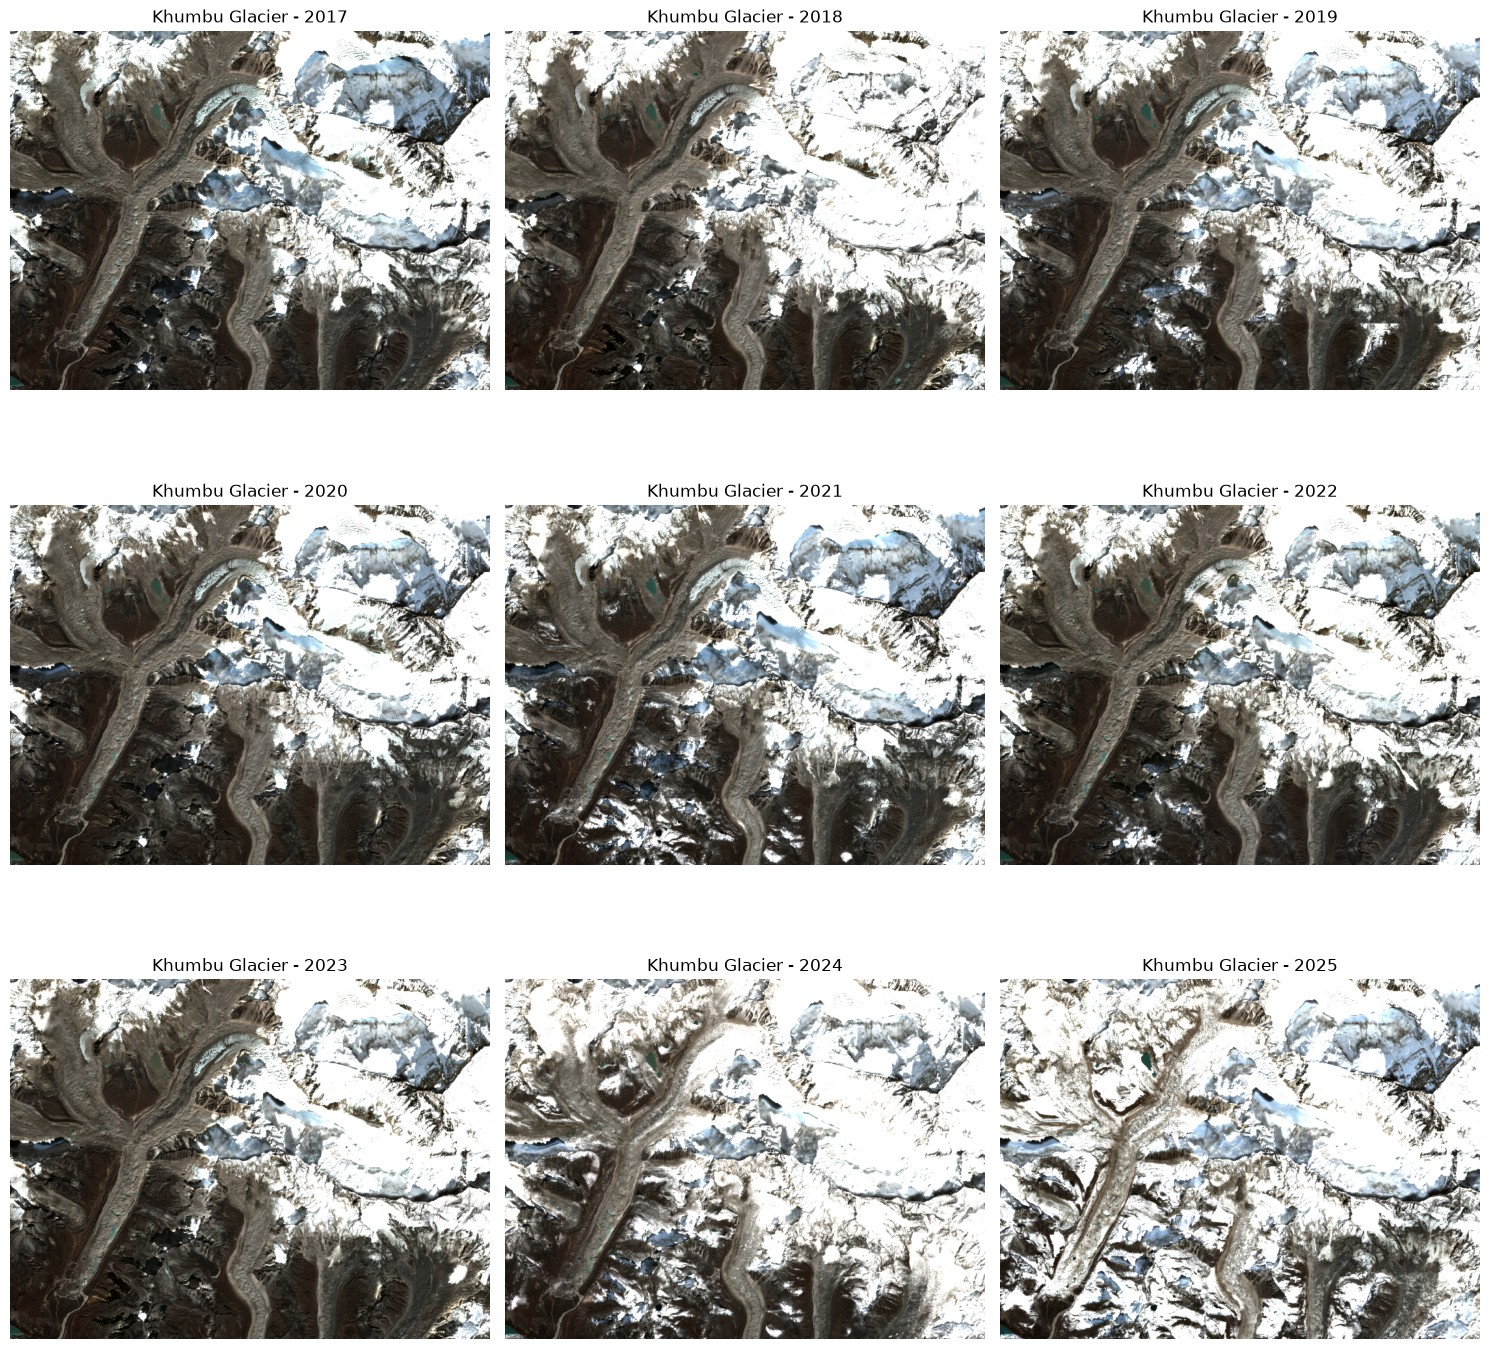

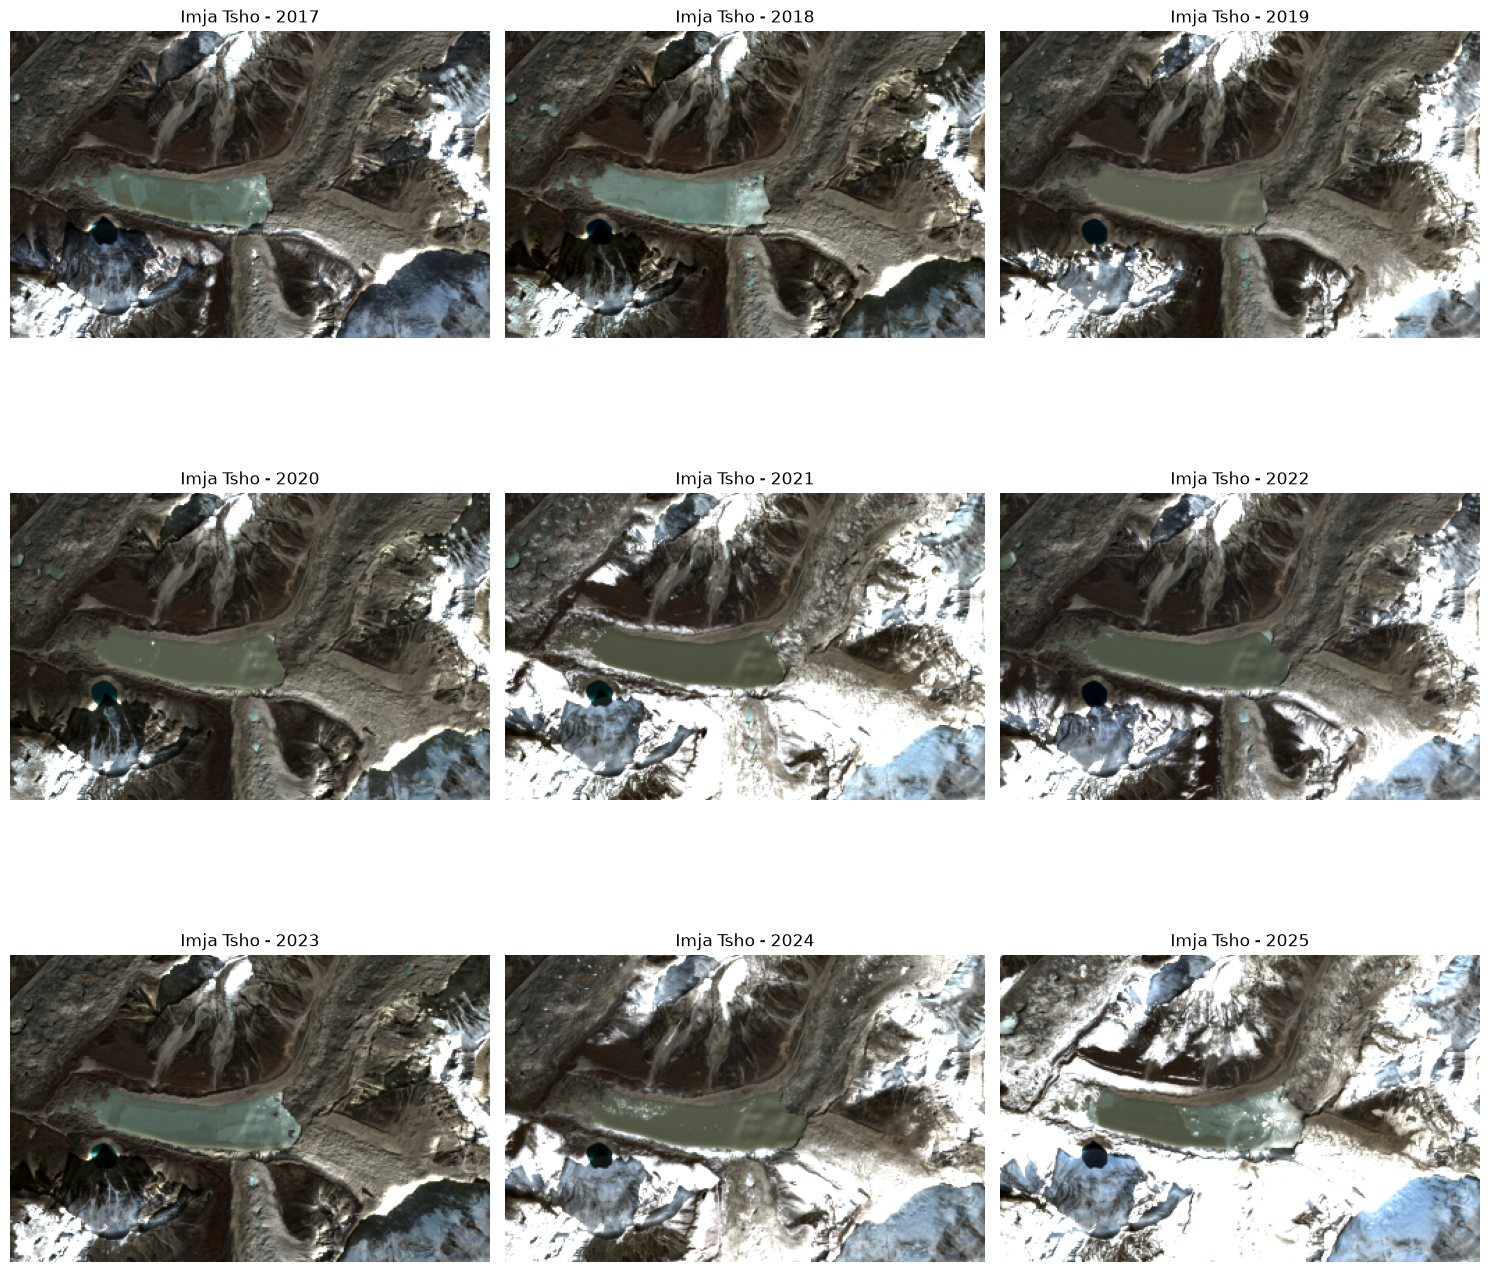

In [29]:
import matplotlib.pyplot as plt


def true_color(image, gain=2.5):
    """RGB composite (B04, B03, B02) scaled to [0, 1] for display."""
    rgb = image[..., [BAND_INDEX["B04"], BAND_INDEX["B03"], BAND_INDEX["B02"]]]
    return np.clip(rgb * gain, 0, 1)


def show_true_color_grid(name, gain=2.5, ncols=3):
    """Display the true-colour image of every year for one area of interest."""
    years = list(images[name])
    nrows = int(np.ceil(len(years) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    for ax in axes.flat:
        ax.axis("off")
    for ax, year in zip(axes.flat, years):
        ax.imshow(true_color(images[name][year], gain))
        ax.set_title(f"{name} - {year}")
    plt.tight_layout()
    plt.show()


# gain=1.5 keeps some detail on snow, which saturates quickly
for name in AOIS:
    show_true_color_grid(name, gain=1.5)